# Validation plots: trajectory comparison and skill scores

Post-processing notebook for the drogued drifter validation. Reads
simulation output produced by notebook 09a and compares simulated
trajectories against observed drifter tracks from the April 2023 Kiel
Bight deployment.

Three simulation types are compared:
- Drogued drifter model (steady-state tilt + effective currents)
- Surface point particle (z=0, AdvectionRK4)
- 3 m point particle (z=3 m, AdvectionRK4)

Includes CMEMS effective coastline rendering, beaching detection,
separation distance, and area-between-tracks skill metric.

## Imports

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import copernicusmarine as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from shapely.geometry import LineString, Polygon

/Users/wrath/src/github.com/geomar-od-lagrange/2025_drogued_drifters/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Parameters

In [2]:
BBOX = [9.8, 12.2, 54.1, 55.1]
LON_MIN, LON_MAX = 9.0, 13.0
LAT_MIN, LAT_MAX = 53.5, 56.0
TIME_START = "2023-04-24"
TIME_END = "2023-05-10"
BEACHING_SPEED_THRESHOLD = 0.02  # m/s
DPI = 200
FIG_WIDTH = 5  # inches

## Load simulation results

In [3]:
# Observed drifter trajectories
obs_df = pd.read_csv(
    "examples/baltic_drifters/data/drifters_clean.csv",
    parse_dates=["date_UTC"],
)
drifter_ids = sorted(obs_df["D_number"].unique())
print(f"Drifter IDs: {drifter_ids}")

# Drogued drifter simulation (CSV from 09a kernel callback)
# time column is float seconds since the FieldSet epoch (TIME_START)
sim_dd = pd.read_csv("output/sim_drogued_drifter.csv")
epoch = pd.Timestamp(TIME_START)
sim_dd["time"] = epoch + pd.to_timedelta(sim_dd["time"], unit="s")

# Point particle simulations (parcels zarr output)
ds_surface = xr.open_zarr("output/sim_surface.zarr")
ds_3m = xr.open_zarr("output/sim_3m.zarr")

Drifter IDs: [np.int64(298), np.int64(299), np.int64(300), np.int64(301), np.int64(302), np.int64(303)]


In [4]:
# Map zarr trajectory index to drifter ID.
# Particles were deployed in the order of sorted drifter IDs.
pid_to_did = dict(enumerate(drifter_ids))

# Extract zarr trajectories into a dict keyed by drifter ID
sim_surface_by_did = {}
sim_3m_by_did = {}

for idx, did in pid_to_did.items():
    for ds, out_dict in [(ds_surface, sim_surface_by_did), (ds_3m, sim_3m_by_did)]:
        lon = ds.lon.values[idx, :]
        lat = ds.lat.values[idx, :]
        time = ds.time.values[idx, :]
        valid = np.isfinite(lon) & np.isfinite(time.astype(np.float64))
        out_dict[did] = {
            "lon": lon[valid],
            "lat": lat[valid],
            "time": time[valid],
        }

## Extract CMEMS effective coastline

The CMEMS Baltic physics model uses an A-grid where velocities are
defined at cell centers. Land cells are identified by the static mask
dataset (`cmems_mod_bal_phy_anfc_static`), where mask=1 is water and
mask=0 is land.

We shade the CMEMS land cells as a semi-transparent overlay so the
effective model coastline is clearly visible without messy contour lines.

In [5]:
ds_static = cm.open_dataset(
    dataset_id="cmems_mod_bal_phy_anfc_static",
    service="static-arco",
)
# mask: 1=water, 0=land, at each depth level
# Use surface level mask for the coastline
mask = ds_static.mask.sel(
    longitude=slice(LON_MIN, LON_MAX),
    latitude=slice(LAT_MIN, LAT_MAX),
).isel(depth=0).load()

# We will shade land cells with pcolormesh instead of extracting contours.
# The land_cmap maps 0 (land) -> light gray, 1 (water) -> transparent.
land_cmap = mcolors.ListedColormap(["lightgray", "none"])

INFO - 2026-03-26T17:17:26Z - Selected dataset version: "202411"


INFO - 2026-03-26T17:17:26Z - Selected dataset part: "bathy"


## Trajectory plots

One figure per drifter showing observed and all three simulated
trajectories, with both the Natural Earth coastline (physical geography)
and the CMEMS effective coastline (model boundary).

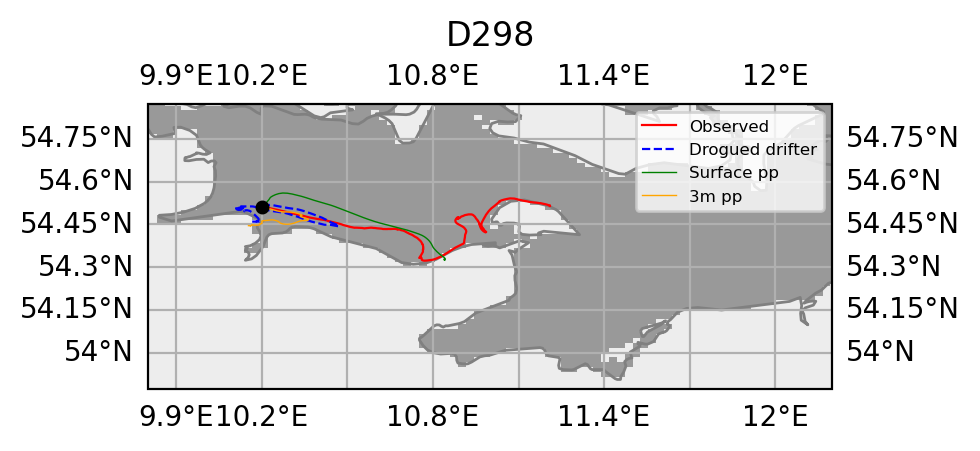

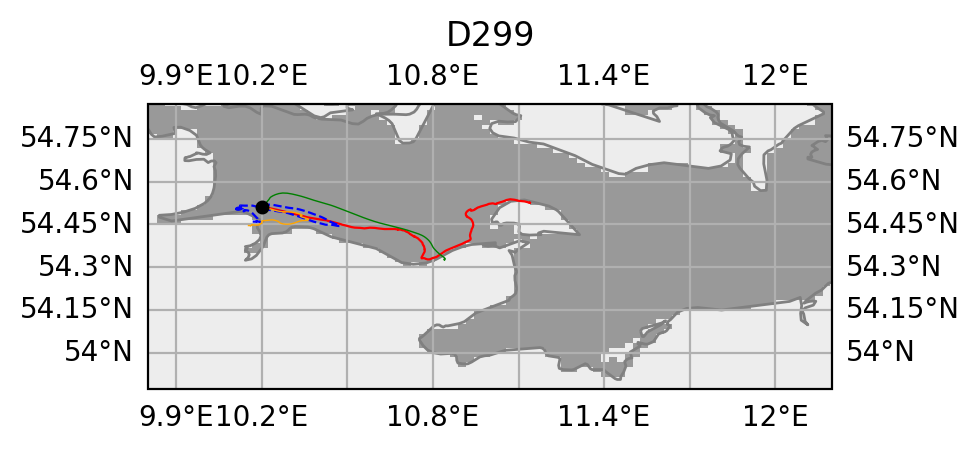

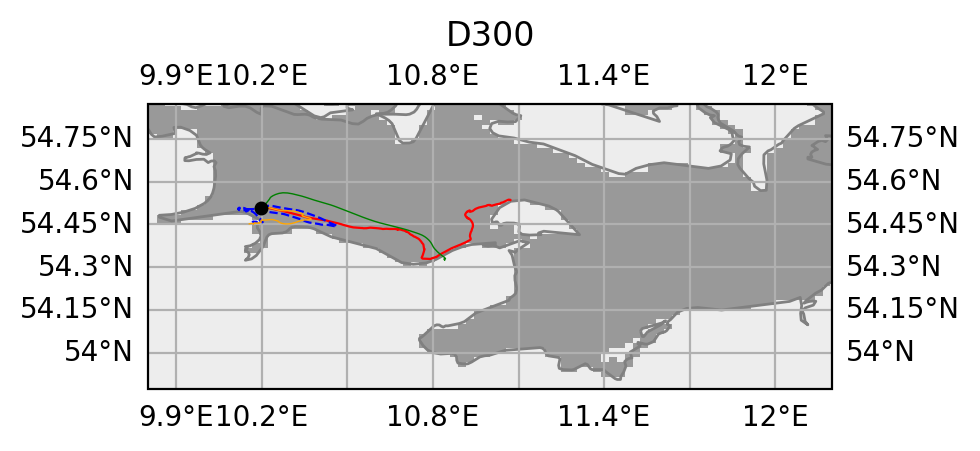

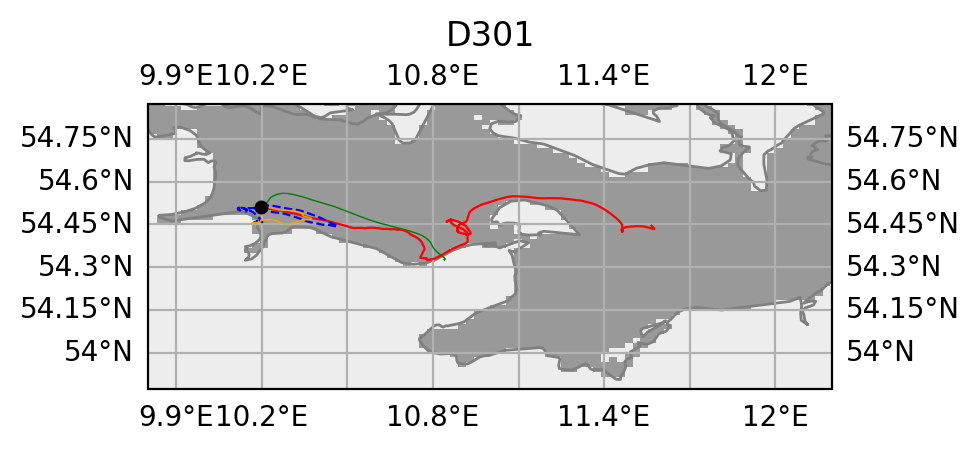

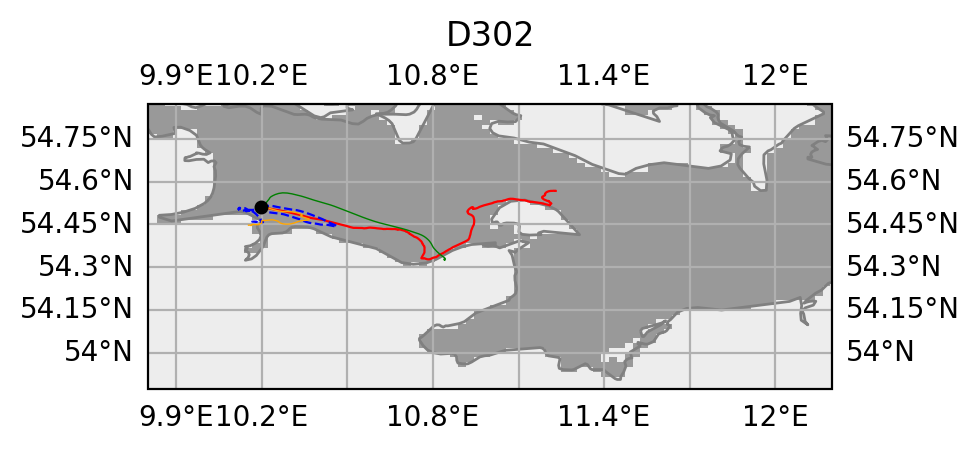

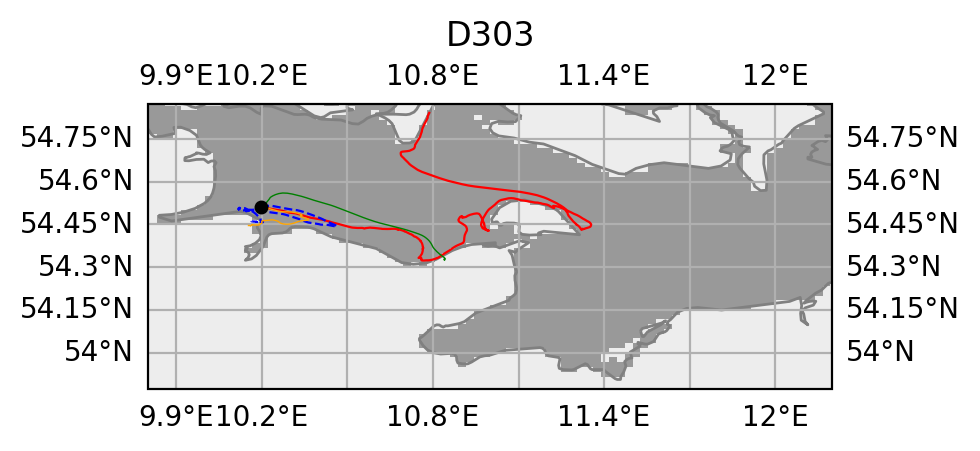

In [6]:
coast_10m = cfeature.NaturalEarthFeature(
    "physical", "coastline", "10m",
    edgecolor="gray", facecolor="none",
)

aspect = (BBOX[3] - BBOX[2]) / ((BBOX[1] - BBOX[0]) * np.cos(np.deg2rad(54.6)))
fig_height = FIG_WIDTH * aspect

for idx, did in enumerate(drifter_ids):
    fig, ax = plt.subplots(
        subplot_kw={"projection": ccrs.PlateCarree()},
        figsize=(FIG_WIDTH, fig_height), dpi=DPI,
    )
    ax.add_feature(coast_10m)
    # Shade CMEMS land cells
    ax.pcolormesh(
        mask.longitude, mask.latitude, mask.values,
        cmap=land_cmap, vmin=0, vmax=1, alpha=0.4, shading="nearest",
        transform=ccrs.PlateCarree(),
    )
    ax.set_extent(BBOX)
    ax.gridlines(draw_labels=True)

    # Observed
    obs = obs_df[obs_df["D_number"] == did]
    ax.plot(obs["Longitude"], obs["Latitude"], color="red", linewidth=0.8,
            label="Observed", transform=ccrs.PlateCarree())

    # Drogued drifter
    dd = sim_dd[sim_dd["D_number"] == did]
    ax.plot(dd["lon"], dd["lat"], color="blue", ls="--", linewidth=0.8,
            label="Drogued drifter", transform=ccrs.PlateCarree())

    # Surface point particle
    s = sim_surface_by_did[did]
    ax.plot(s["lon"], s["lat"], color="green", linewidth=0.5,
            label="Surface pp", transform=ccrs.PlateCarree())

    # 3 m point particle
    d3 = sim_3m_by_did[did]
    ax.plot(d3["lon"], d3["lat"], color="orange", linewidth=0.5,
            label="3m pp", transform=ccrs.PlateCarree())

    # Deployment marker
    dep = obs.iloc[0]
    ax.plot(dep["Longitude"], dep["Latitude"], "ko", markersize=4,
            transform=ccrs.PlateCarree())

    ax.set_title(f"D{did}")
    if idx == 0:
        ax.legend(fontsize=6, loc="best")

    plt.tight_layout()
    plt.show()

## Detect beaching in simulated trajectories

Two complementary beaching detection methods:

1. **Speed-based**: compute speed from consecutive positions using
   haversine distance. Apply a 1-hour rolling mean. If the rolling mean
   speed drops below 0.02 m/s, the particle is considered beached.

2. **Distance to CMEMS coastline**: for each simulated position, check
   whether it falls inside a CMEMS land cell (the mask value is 0). If
   so, the particle has crossed the effective coastline and is beached.

For each simulated trajectory, we find the earliest beaching time from
either method and truncate the trajectory there.

In [7]:
def haversine_km(lon1, lat1, lon2, lat2):
    """Great-circle distance in km between two points."""
    R = 6371.0
    dlat = np.deg2rad(lat2 - lat1)
    dlon = np.deg2rad(lon2 - lon1)
    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(np.deg2rad(lat1)) * np.cos(np.deg2rad(lat2)) * np.sin(dlon / 2) ** 2
    )
    return R * 2 * np.arcsin(np.sqrt(a))


def interp_sim_to_obs(sim_time, sim_lon, sim_lat, obs_time):
    """Interpolate simulated lon/lat to observed timestamps."""
    sim_t = sim_time.astype(np.float64)
    obs_t = obs_time.astype(np.float64)
    return np.interp(obs_t, sim_t, sim_lon), np.interp(obs_t, sim_t, sim_lat)

In [8]:
def detect_beaching_speed(lon, lat, time_ns, threshold_ms=BEACHING_SPEED_THRESHOLD, window_h=1):
    """Detect beaching using speed-based criterion.

    Returns the index of the first beached position, or len(lon) if no
    beaching is detected.
    """
    if len(lon) < 2:
        return len(lon)

    dt_s = np.diff(time_ns.astype(np.float64)) / 1e9  # seconds
    dist_km = haversine_km(lon[:-1], lat[:-1], lon[1:], lat[1:])
    speed_ms = (dist_km * 1000.0) / np.maximum(dt_s, 1.0)

    # Rolling mean over window_h hours
    # Assume hourly output: window size = window_h
    window = max(1, window_h)
    speed_padded = np.concatenate([[speed_ms[0]], speed_ms])
    speed_rolling = pd.Series(speed_padded).rolling(window, min_periods=1).mean().values

    beached = speed_rolling < threshold_ms
    if np.any(beached):
        return int(np.argmax(beached))
    return len(lon)


def detect_beaching_land(lon, lat, mask_da):
    """Detect beaching by checking if position falls on a CMEMS land cell.

    Returns the index of the first land position, or len(lon) if none.
    """
    mask_vals = mask_da.sel(
        longitude=xr.DataArray(lon, dims="pos"),
        latitude=xr.DataArray(lat, dims="pos"),
        method="nearest",
    ).values
    on_land = mask_vals < 0.5
    if np.any(on_land):
        return int(np.argmax(on_land))
    return len(lon)


def find_beaching_index(lon, lat, time_ns, mask_da):
    """Combined beaching detection: earliest of speed or land mask."""
    idx_speed = detect_beaching_speed(lon, lat, time_ns)
    idx_land = detect_beaching_land(lon, lat, mask_da)
    return min(idx_speed, idx_land)

In [9]:
# Apply beaching detection and truncate simulated trajectories
sim_dd_trunc = {}
sim_surface_trunc = {}
sim_3m_trunc = {}

for did in drifter_ids:
    # Drogued drifter
    dd_d = sim_dd[sim_dd["D_number"] == did]
    lon_dd = dd_d["lon"].values
    lat_dd = dd_d["lat"].values
    time_dd = dd_d["time"].values.astype("datetime64[ns]")
    bi = find_beaching_index(lon_dd, lat_dd, time_dd, mask)
    sim_dd_trunc[did] = {"lon": lon_dd[:bi], "lat": lat_dd[:bi], "time": time_dd[:bi]}

    # Surface point particle
    s = sim_surface_by_did[did]
    bi = find_beaching_index(s["lon"], s["lat"], s["time"], mask)
    sim_surface_trunc[did] = {k: v[:bi] for k, v in s.items()}

    # 3 m point particle
    d3 = sim_3m_by_did[did]
    bi = find_beaching_index(d3["lon"], d3["lat"], d3["time"], mask)
    sim_3m_trunc[did] = {k: v[:bi] for k, v in d3.items()}

    print(
        f"D{did}: DD {len(sim_dd_trunc[did]['lon'])}/{len(lon_dd)}, "
        f"surf {len(sim_surface_trunc[did]['lon'])}/{len(s['lon'])}, "
        f"3m {len(sim_3m_trunc[did]['lon'])}/{len(d3['lon'])}"
    )

D298: DD 535/3451, surf 60/289, 3m 8/289
D299: DD 546/3446, surf 60/289, 3m 8/289
D300: DD 529/3457, surf 58/288, 3m 7/288
D301: DD 535/3456, surf 59/288, 3m 7/288
D302: DD 529/3457, surf 59/288, 3m 7/288
D303: DD 532/3457, surf 59/288, 3m 7/288


## Separation distance vs time

Haversine separation between simulated and observed positions as a
function of time since deployment. Simulated positions are interpolated
to observed timestamps. Only pre-beaching portions of the simulated
trajectories are used.

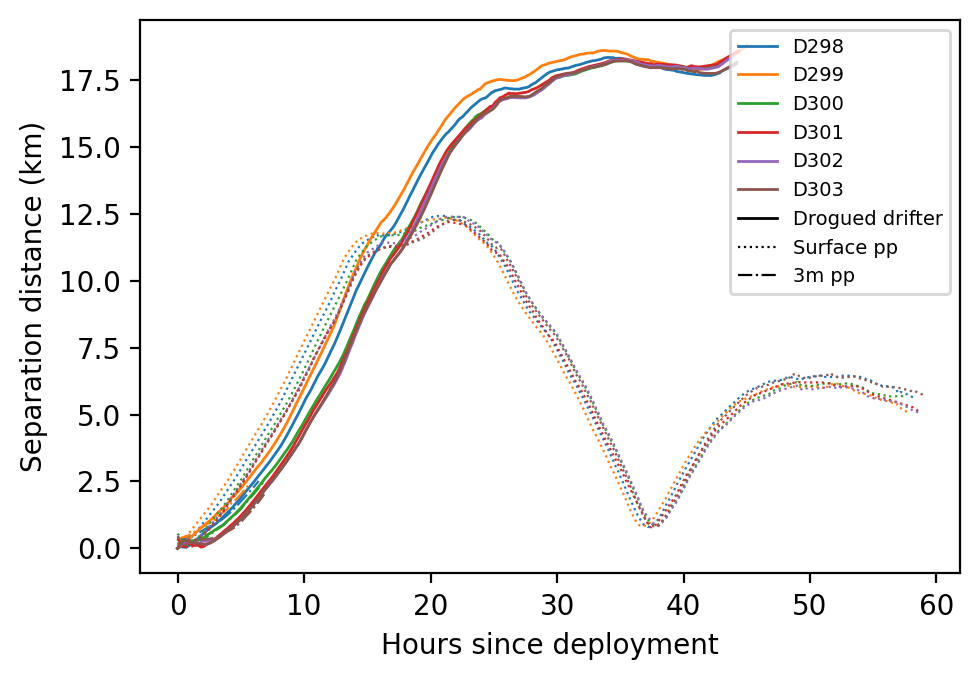

In [10]:
colors = plt.cm.tab10(range(len(drifter_ids)))

fig, ax = plt.subplots(figsize=(FIG_WIDTH, 3.5), dpi=DPI)

for i, did in enumerate(drifter_ids):
    obs = obs_df[obs_df["D_number"] == did]
    obs_time = obs["date_UTC"].values.astype("datetime64[ns]")
    obs_lon = obs["Longitude"].values
    obs_lat = obs["Latitude"].values
    t0 = obs_time[0]
    hours_obs = (obs_time - t0).astype(np.float64) / 3.6e12

    for sim_dict, ls, lw in [
        (sim_dd_trunc, "-", 1.0),
        (sim_surface_trunc, ":", 0.8),
        (sim_3m_trunc, "-.", 0.8),
    ]:
        sim = sim_dict[did]
        if len(sim["lon"]) < 2:
            continue
        # Truncate obs to sim time range
        sim_end = sim["time"][-1]
        obs_mask = obs_time <= sim_end
        if obs_mask.sum() < 2:
            continue
        ot = obs_time[obs_mask]
        ol = obs_lon[obs_mask]
        oa = obs_lat[obs_mask]
        h = (ot - t0).astype(np.float64) / 3.6e12

        sim_lon_i, sim_lat_i = interp_sim_to_obs(
            sim["time"], sim["lon"], sim["lat"], ot,
        )
        sep = haversine_km(sim_lon_i, sim_lat_i, ol, oa)
        label = f"D{did}" if ls == "-" else None
        ax.plot(h, sep, color=colors[i], ls=ls, lw=lw, label=label)

# Style legend entries
ax.plot([], [], color="k", ls="-", lw=1.0, label="Drogued drifter")
ax.plot([], [], color="k", ls=":", lw=0.8, label="Surface pp")
ax.plot([], [], color="k", ls="-.", lw=0.8, label="3m pp")

ax.set_xlabel("Hours since deployment")
ax.set_ylabel("Separation distance (km)")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## Area-between-tracks metric

Geometric measure of trajectory agreement: build a polygon from the
observed track (forward) and simulated track (reversed), then compute
the enclosed area divided by the observed path length. This gives an
average separation distance in meters.

Both tracks are resampled to common hourly timestamps before computing
the metric. Simulated tracks are truncated at beaching time, and the
observed track is restricted to the same time window.

In [11]:
DEG2M_LAT = 111320.0


def tracks_area_metric(obs_lon, obs_lat, sim_lon, sim_lat, ref_lat):
    """Average separation between two tracks using the enclosed area.

    Builds a polygon from obs-forward + sim-reversed, computes its area,
    and divides by the observed path length to get an average separation
    distance in meters.
    """
    deg2m_lon = DEG2M_LAT * np.cos(np.radians(ref_lat))

    # Convert to meters
    obs_x = obs_lon * deg2m_lon
    obs_y = obs_lat * DEG2M_LAT
    sim_x = sim_lon * deg2m_lon
    sim_y = sim_lat * DEG2M_LAT

    # Build polygon: obs forward, sim backward
    coords = list(zip(obs_x, obs_y)) + list(zip(sim_x[::-1], sim_y[::-1]))
    if len(coords) < 3:
        return np.nan
    poly = Polygon(coords)
    area = poly.area  # m^2

    # Observed path length
    obs_line = LineString(zip(obs_x, obs_y))
    path_length = obs_line.length  # m

    if path_length < 1:
        return np.nan
    return area / path_length  # meters (average separation)


def resample_to_hourly(time_ns, lon, lat, t_start, t_end):
    """Resample a trajectory to hourly timestamps using linear interpolation.

    Returns (hourly_times, hourly_lon, hourly_lat).
    """
    hourly_times = np.arange(t_start, t_end, np.timedelta64(1, "h"))
    if len(hourly_times) < 2:
        return hourly_times, np.array([]), np.array([])
    t_float = time_ns.astype(np.float64)
    h_float = hourly_times.astype(np.float64)
    h_lon = np.interp(h_float, t_float, lon)
    h_lat = np.interp(h_float, t_float, lat)
    return hourly_times, h_lon, h_lat

In [12]:
rows = []

for did in drifter_ids:
    obs = obs_df[obs_df["D_number"] == did]
    obs_time = obs["date_UTC"].values.astype("datetime64[ns]")
    obs_lon = obs["Longitude"].values
    obs_lat = obs["Latitude"].values
    ref_lat = obs_lat[0]

    sims = [
        ("Drogued drifter", sim_dd_trunc[did]),
        ("Surface pp", sim_surface_trunc[did]),
        ("3m pp", sim_3m_trunc[did]),
    ]

    for sim_name, sim in sims:
        if len(sim["lon"]) < 2:
            rows.append({"Drifter": f"D{did}", "Type": sim_name,
                         "Avg sep (m)": np.nan, "Hours": 0})
            continue

        # Common time window: obs start to min(obs end, sim end)
        t_start = obs_time[0]
        sim_time = sim["time"].astype("datetime64[ns]")
        t_end = min(obs_time[-1], sim_time[-1])
        if t_end <= t_start:
            rows.append({"Drifter": f"D{did}", "Type": sim_name,
                         "Avg sep (m)": np.nan, "Hours": 0})
            continue

        # Resample both tracks to common hourly grid
        h_times, h_obs_lon, h_obs_lat = resample_to_hourly(
            obs_time, obs_lon, obs_lat, t_start, t_end,
        )
        _, h_sim_lon, h_sim_lat = resample_to_hourly(
            sim_time, sim["lon"], sim["lat"], t_start, t_end,
        )

        if len(h_obs_lon) < 2:
            rows.append({"Drifter": f"D{did}", "Type": sim_name,
                         "Avg sep (m)": np.nan, "Hours": 0})
            continue

        avg_sep = tracks_area_metric(
            h_obs_lon, h_obs_lat, h_sim_lon, h_sim_lat, ref_lat,
        )
        duration_h = (t_end - t_start) / np.timedelta64(1, "h")
        rows.append({"Drifter": f"D{did}", "Type": sim_name,
                     "Avg sep (m)": avg_sep, "Hours": duration_h})

result_df = pd.DataFrame(rows)
# Format for display
result_df["Avg sep (km)"] = result_df["Avg sep (m)"] / 1000.0
print(result_df[["Drifter", "Type", "Hours", "Avg sep (m)", "Avg sep (km)"]].to_string(index=False))

# Summary per simulation type
print("\n--- Mean area-based separation by simulation type ---")
summary = result_df.groupby("Type")[["Avg sep (m)", "Avg sep (km)"]].mean()
print(summary.to_string())

Drifter            Type     Hours  Avg sep (m)  Avg sep (km)
   D298 Drogued drifter 44.500000  1046.468404      1.046468
   D298      Surface pp 58.476389  4127.181511      4.127182
   D298           3m pp  6.476389   231.005218      0.231005
   D299 Drogued drifter 45.416667  1091.348975      1.091349
   D299      Surface pp 58.020833  4068.403379      4.068403
   D299           3m pp  6.020833   214.494746      0.214495
   D300 Drogued drifter 44.000000   900.691569      0.900692
   D300      Surface pp 58.000000  4207.970260      4.207970
   D300           3m pp  7.000000    30.931299      0.030931
   D301 Drogued drifter 44.500000   973.810678      0.973811
   D301      Surface pp 58.910000  4030.122642      4.030123
   D301           3m pp  6.910000    67.478969      0.067479
   D302 Drogued drifter 44.000000   894.425512      0.894426
   D302      Surface pp 58.958333  4125.880050      4.125880
   D302           3m pp  6.958333   114.016738      0.114017
   D303 Drogued drifter 